# Lecture 6 — Measuring Performance and Regularization
## Lab Notebook · Deep Learning · UCU

In Notebook 4, we tuned the *training dynamics* — loss, optimizer, initialization, batch size, schedule — on FashionMNIST. We held the dataset fixed and trained until the optimizer converged. In this notebook, we step back and ask: *when should we stop, and what should we change so the model generalizes?* We also switch to a new problem — **UCI Covertype**, predicting forest cover type from cartographic features — where regularization pays off.

### By the end of this notebook, you will:

1. Build a proper train / validation / test split in PyTorch, including stratified splits and per-class diagnostics.
2. Tune hyperparameters with `sklearn.model_selection.ParameterGrid` and with **Optuna**.
3. Compare regularization techniques — weight decay (AdamW), dropout, label smoothing, early stopping — under a fair protocol.
4. Use learning-rate schedulers (`StepLR`, `CosineAnnealingLR`, `ReduceLROnPlateau`) and pick the right one for the situation.
5. *(Optional)* Observe **double descent** — test error as a function of model width, past the interpolation threshold.

> **Note.** Data augmentation belongs naturally to image data; we will meet it in Notebook 6 when we introduce CNNs.

### Recurring practical recommendations

Throughout this notebook, a few pieces of advice will come up repeatedly:

- **Hidden dimensions as powers of two** (32, 64, 128, 256, 512, …). Aligned matmul kernels run faster on both CPU and GPU, and powers of two are the community convention.
- **Read the docs before choosing hyperparameters.** Whenever a new PyTorch / sklearn / Optuna function is introduced, open its documentation and understand every argument you touch — and every argument you are leaving at its default.
- **Log-scale for hyperparameters that span orders of magnitude** (learning rate, weight decay); **linear scale for bounded quantities** (dropout probability, label smoothing).
- **If the best value lands on the edge of the search space, extend the search** in that direction — the true optimum is likely outside the current grid.

### Useful references

| Resource | Link |
|---|---|
| Lecture 6 notes | [`../../lectures/lecture 6/notes.md`](../../lectures/lecture%206/notes.md) |
| PyTorch — `random_split` | https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split |
| PyTorch — `AdamW` | https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html |
| PyTorch — `Dropout` | https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html |
| PyTorch — `CrossEntropyLoss` | https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html |
| PyTorch — `lr_scheduler` | https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate |
| scikit-learn — `fetch_covtype` | https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_covtype.html |
| scikit-learn — `ParameterGrid` | https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html |
| Optuna docs | https://optuna.readthedocs.io |
| UCI Covertype dataset | https://archive.ics.uci.edu/dataset/31/covertype |
| Prince, *Understanding Deep Learning* | Chapters 8 & 9 |


## Setup

If you are on Colab, uncomment the `pip install` line below.

In [1]:
!pip install -q optuna torchinfo

import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split

import sklearn
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import optuna
from torchinfo import summary

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4 = "#19326E", "#50ACB0", "#CD742A", "#A3477F"
C5, C6, C7     = "#907FAB", "#4294CC", "#89A943"
UCU_COLORS = [C1, C2, C3, C4, C5, C6, C7]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.5 MB/s eta 0:00:00
Using device: cuda


---

## Section 1 — Train / Validation / Test the PyTorch Way

The UCI **Covertype** dataset contains ~581k observations from the Roosevelt National Forest (Colorado). Each sample has **54 features** — 10 continuous (elevation, slope, distances, hillshade channels) and 44 binary (wilderness-area and soil-type indicators) — and a **label in {1, …, 7}** representing the dominant forest cover type.

The classes are **naturally imbalanced**: class 2 dominates (~49 %), class 4 is rare (~0.5 %). This will make stratification and per-class diagnostics actually matter.

### Exercise 1.1 — Load and inspect the dataset

Load Covertype with `sklearn.datasets.fetch_covtype(as_frame=False)`. Store the features in `X` and the labels in `y`. Remember to **remap the labels from `{1,…,7}` to `{0,…,6}`** so they work with PyTorch's `CrossEntropyLoss`. Print:

- The shape of `X` and `y`.
- The unique class values and their counts.


In [2]:
covtype = sklearn.datasets.fetch_covtype(as_frame=False)
X = covtype.data
y = covtype.target - 1  # Remap from {1,...,7} to {0,...,6}
# After your code, X should be (N, 54) float array, y should be (N,) int array with values in {0, ..., 6}
print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", np.unique(y, return_counts=True))

X shape: (581012, 54) | y shape: (581012,)
Classes: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([211840, 283301,  35754,   2747,   9493,  17367,  20510]))


*Provided:* bar chart of class counts on the full dataset — notice the imbalance.

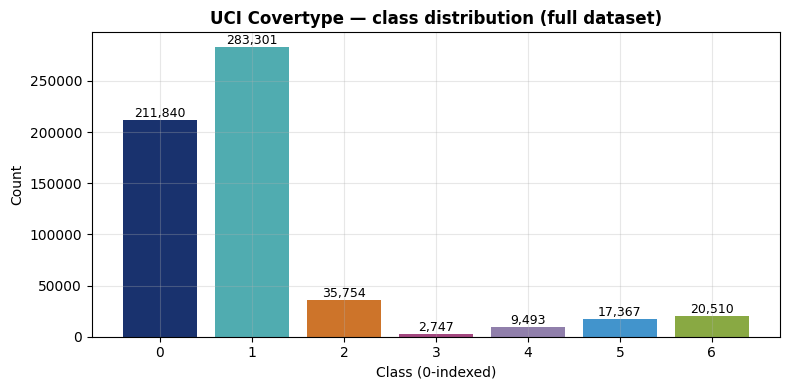

In [3]:
classes, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color=UCU_COLORS)
ax.set_xlabel("Class (0-indexed)")
ax.set_ylabel("Count")
ax.set_title("UCI Covertype — class distribution (full dataset)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for c, n in zip(classes, counts):
    ax.text(c, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


### Exercise 1.2 — Stratified subsample to 30 000 examples

The full dataset is too big for a lab session. Use `sklearn.model_selection.train_test_split` with `stratify=y` to carve off exactly **30 000** samples (preserving class ratios). Discard the rest.

Call the resulting arrays `X_pool` and `y_pool`. Then re-plot the class distribution and compare with the full dataset.

Pool shapes: (30000, 54) (30000,)


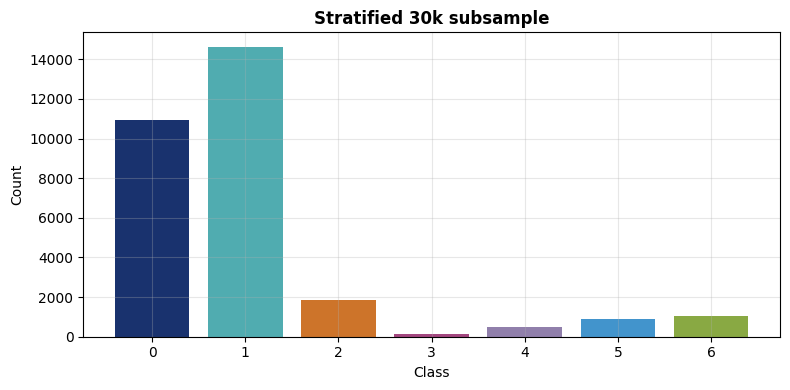

In [4]:
X_pool, _, y_pool, _ = sklearn.model_selection.train_test_split(X, y, train_size=30000, stratify=y)
print("Pool shapes:", X_pool.shape, y_pool.shape)

classes_p, counts_p = np.unique(y_pool, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes_p, counts_p, color=UCU_COLORS)
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_title("Stratified 30k subsample", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Exercise 1.3 — Three-way split with `random_split` (first attempt)

Wrap `X_pool` and `y_pool` in a `TensorDataset`. Then use `torch.utils.data.random_split` to divide it into:

- `train_ds_rand` — 21 000 samples
- `val_ds_rand`   — 3 000 samples
- `test_ds_rand`  — 6 000 samples

Pass a fixed `generator=torch.Generator().manual_seed(SEED)` so the split is reproducible.

> **Hint.** `TensorDataset` expects `torch.Tensor` objects, not NumPy arrays. Convert carefully: features → `float32`, labels → `long`.


In [5]:
X_tensor, y_tensor = torch.tensor(X_pool, dtype=torch.float32), torch.tensor(y_pool, dtype=torch.long)
dataset = TensorDataset(X_tensor, y_tensor)
random_split = torch.utils.data.random_split(dataset, [21000, 3000, 6000], generator=torch.Generator().manual_seed(SEED))
train_ds_rand, val_ds_rand, test_ds_rand = random_split
print(len(train_ds_rand), len(val_ds_rand), len(test_ds_rand))

21000 3000 6000


### Exercise 1.4 — Inspect the class distribution of each split

Implement a helper `class_counts(subset, num_classes=7)` that iterates over a PyTorch `Subset` / `Dataset` and returns a `torch.Tensor` of size `(num_classes,)` with the per-class counts.

Then produce a 1×3 bar chart showing the class distribution of `train_ds_rand`, `val_ds_rand`, `test_ds_rand`.

In [6]:
def class_counts(subset, num_classes=7):
    counts = torch.zeros(num_classes, dtype=torch.long)
    for x, y in subset:
        counts[y] += 1
    return counts

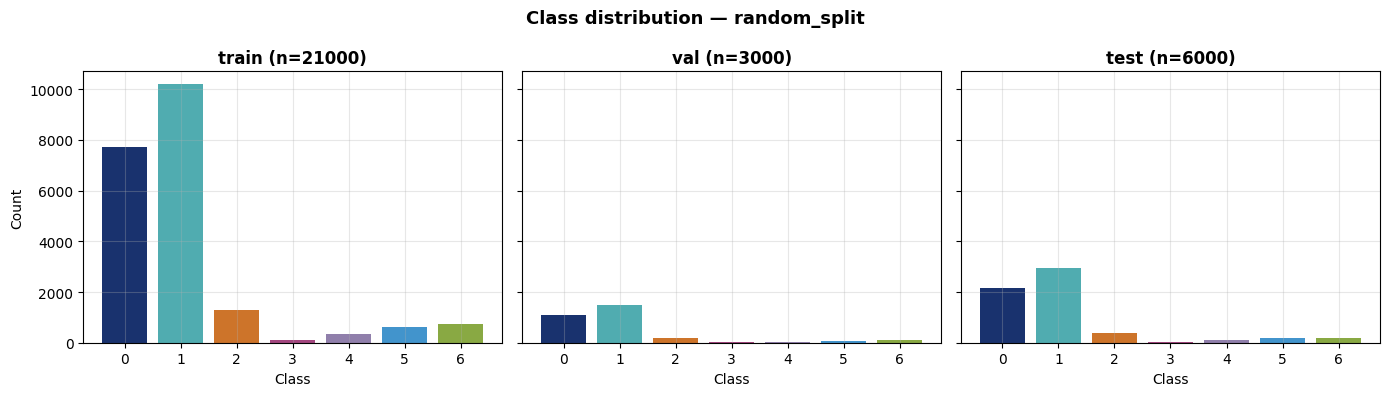

In [7]:
# Plot the three distributions side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes,
                        [train_ds_rand, val_ds_rand, test_ds_rand],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — random_split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.1** — Compare your three plots. Did `random_split` preserve the class ratios? Look at the rarest class — are there enough samples in the validation set to estimate its accuracy reliably?

El `random_split` preserva las proporciones de clases de manera aproximada pero no garantizada, porque divide de forma aleatoria sin tener en cuenta las etiquetas. En los plots se puede ver que la estructura general se mantiene (clase 1 es la más frecuente, clase 0 la segunda), pero hay variaciones notables en las clases minoritarias.

El caso más crítico es la clase 3, que es la más rara del dataset (solo 2747 muestras en los 581k originales, es decir cerca del 0.47%). En el pool de 30k eso equivale a unos 141 ejemplos. Con el split aleatorio, al conjunto de validación le corresponden aproximadamente el 10% de esos, es decir unas 14 muestras. En el plot de validación se puede ver que las barras de las clases 3, 4, 5 y 6 son casi invisibles.

Con 14 muestras de una clase, cualquier estimación de accuracy para esa clase tiene un margen de error enorme. Si el modelo clasifica correctamente 12 de esas 14, la accuracy estimada es del 86%, pero el intervalo de confianza real puede ir del 60% al 96%. Esa estimación no es confiable para tomar decisiones. Ese es exactamente el problema que resuelve la división estratificada del ejercicio 1.5: fuerza a que cada split tenga la misma proporción de cada clase, garantizando que incluso las clases raras tengan representación proporcional en validación y test.

### Exercise 1.5 — Stratified three-way split

Now redo the split with stratification. Use `sklearn.model_selection.train_test_split` **twice**:

1. First, split `X_pool, y_pool` into `(X_trainval, y_trainval)` + `(X_test, y_test)` with 6 000 test samples, `stratify=y_pool`.
2. Then split `(X_trainval, y_trainval)` into `(X_train, y_train)` + `(X_val, y_val)` with 3 000 validation samples, `stratify=y_trainval`.

Wrap each pair in a `TensorDataset` called `train_ds`, `val_ds`, `test_ds`. Re-plot the class distributions with the same helper.

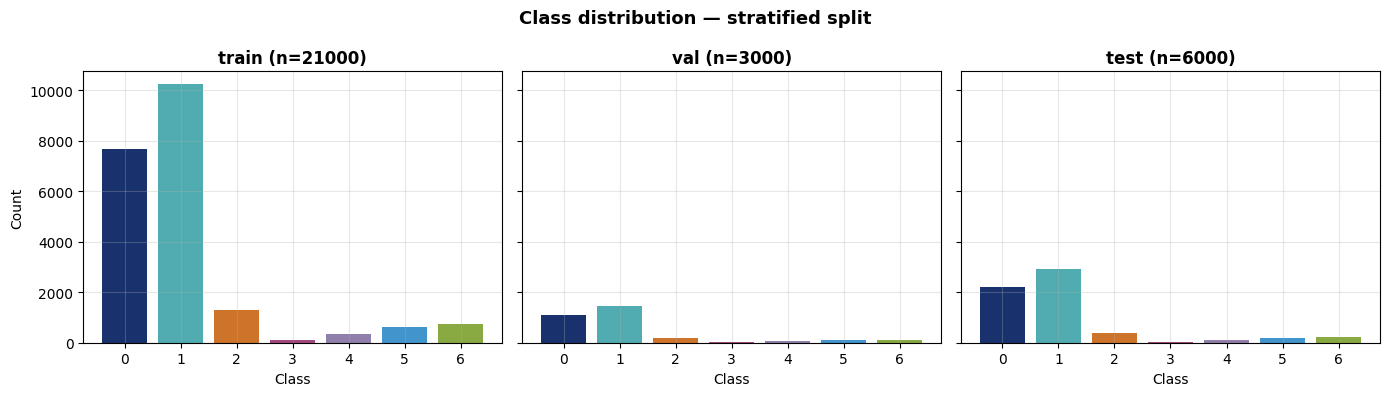

In [8]:
X_trainval, X_test, y_trainval, y_test = sklearn.model_selection.train_test_split(
    X_pool, y_pool,
    test_size=6000,
    stratify=y_pool,
    random_state=SEED
)

X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
    X_trainval, y_trainval,
    test_size=3000,
    stratify=y_trainval,
    random_state=SEED
)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
    )
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes, [train_ds, val_ds, test_ds],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — stratified split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.2** — Why does stratification matter *more* for Covertype than it did for FashionMNIST? What would happen if the rare class ended up entirely in one split?

Las proporciones ahora son consistentes entre los tres conjuntos, incluso para las clases raras. Eso se ve porque las barras de clases 3, 4, 5 y 6 tienen alturas proporcionales en train, val y test. La estratificación importa mucho más en Covertype que en FashionMNIST porque los datasets tienen naturalezas muy distintas. FashionMNIST tiene exactamente 6000 ejemplos por clase en entrenamiento, es decir, está perfectamente balanceado. Con ese balance, un split aleatorio casi siempre va a preservar las proporciones por pura probabilidad. En Covertype, en cambio, la clase 1 representa cerca del 49% del dataset mientras que la clase 3 representa apenas el 0.47%, una razón de desbalance de aproximadamente 100 a 1. Con ese nivel de desbalance, un split aleatorio puede fácilmente dejar a la clase rara sin representación adecuada en alguno de los conjuntos.

Si la clase rara terminara completamente en un solo split, las consecuencias serían distintas según cuál:

Si cae solo en entrenamiento: el modelo la vería durante el aprendizaje, pero nunca sería evaluado sobre ella en validación ni en test. Eso significa que el tuneo de hiperparámetros sería ciego al rendimiento en esa clase, y la evaluación final estaría sobreestimada porque no incluiría los casos difíciles.

Si cae solo en validación o test: el modelo nunca la vio durante el entrenamiento, así que no aprendió ninguna representación útil. El accuracy reportado para esa clase sería cercano al azar, y la métrica global quedaría sesgada hacia abajo de forma artificial.

En ambos casos, el modelo resultante sería inútil para esa clase en producción, y lo peor es que no habría forma de saberlo durante el desarrollo.


### Exercise 1.6 — Standardize features without leakage

Fit a `StandardScaler` **on the training split only**, then `.transform()` the training, validation and test features. Overwrite the `X` tensors inside the datasets with the scaled values.

> **Why this matters.** If you fit the scaler on the whole dataset before splitting, statistics from val/test leak into training — your held-out performance will look better than it really is. This is one of the most common mistakes in practical ML.


In [10]:
# Creamos el scaler y lo ajustamos SOLO con los features de entrenamiento
scaler = StandardScaler()
scaler.fit(train_ds.tensors[0].numpy())

# Aplicamos la transformación a los tres conjuntos usando el mismo scaler
X_train_scaled = scaler.transform(train_ds.tensors[0].numpy())
X_val_scaled   = scaler.transform(val_ds.tensors[0].numpy())
X_test_scaled  = scaler.transform(test_ds.tensors[0].numpy())

# Sobreescribimos los tensores de features dentro de cada TensorDataset
train_ds.tensors = (torch.tensor(X_train_scaled, dtype=torch.float32), train_ds.tensors[1])
val_ds.tensors   = (torch.tensor(X_val_scaled,   dtype=torch.float32), val_ds.tensors[1])
test_ds.tensors  = (torch.tensor(X_test_scaled,  dtype=torch.float32), test_ds.tensors[1])

### Exercise 1.7 — Build the `DataLoader`s

Create three `DataLoader`s: `train_loader`, `val_loader`, `test_loader` with a bath size of 256. Explore the `shuffle`, `pin_memory` and `num_workers` parameters. Skim the [`DataLoader` documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) to understand what each of these flags does.

In [11]:
# Creamos los tres DataLoaders para train, val y test
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          pin_memory=True, num_workers=0)

val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          pin_memory=True, num_workers=0)

test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          pin_memory=True, num_workers=0)

> **Question 1.3** — Why does only the training loader use `shuffle=True`? What does `pin_memory=True` do, and when does it actually help?

**¿Por qué solo el training loader usa `shuffle=True`?**

Durante el entrenamiento, el orden en que el modelo ve los ejemplos importa. Si los batches siempre vienen en el mismo orden, el optimizador puede desarrollar sesgos: los gradientes de cada batch serían sistemáticamente parecidos entre epochs, lo que hace que el descenso por gradiente explore el espacio de parámetros de forma menos rica. Mezclar los datos en cada epoch garantiza que cada batch sea una muestra aproximadamente representativa del dataset completo, lo que estabiliza el entrenamiento y ayuda a escapar de mínimos locales.

En validación y test, en cambio, solo estamos midiendo el rendimiento del modelo sin actualizar pesos. El resultado final (loss, accuracy) es el mismo independientemente del orden en que se procesen los ejemplos, porque simplemente se acumula la métrica sobre todo el conjunto. Mezclar solo agregaría costo computacional sin ningún beneficio, y podría dificultar la reproducibilidad de diagnósticos.

**¿Qué hace `pin_memory=True` y cuándo ayuda realmente?**

La memoria RAM normal puede ser movida por el sistema operativo (paginada) a disco en cualquier momento. Cuando PyTorch necesita transferir un tensor de CPU a GPU, si ese tensor está en memoria paginable, primero tiene que copiarlo a una zona "pinned" (bloqueada, no paginable) y recién después enviarlo a la GPU. Con `pin_memory=True`, el DataLoader reserva los tensores directamente en memoria pinned desde el principio, eliminando esa copia intermedia.

Esto ayuda en la práctica solo cuando hay una GPU disponible y el cuello de botella del entrenamiento está en la transferencia CPU-GPU. En nuestro caso, corriendo en CPU pura, `pin_memory=True` no tiene efecto medible. Pero es una buena práctica dejarlo activado porque el mismo código funcionará más rápido sin cambios si el día de mañana se corre en una máquina con GPU.

---

## Section 2 — Making Overfitting Visible

Now we build a deliberately **over-parameterized MLP** and train it long enough that overfitting becomes obvious.

### The model

A 3-hidden-layer MLP: `54 → 256 → 256 → 256 → 7`. With ~150 k parameters for 21 k training samples, the model has far more capacity than the problem needs — it will memorize.


In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=256, out_dim=7, p_drop=0.0):
        super().__init__()
        layers = []
        dims = [in_dim, hidden_dim, hidden_dim, hidden_dim]
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.ReLU()]
            if p_drop > 0:
                layers += [nn.Dropout(p_drop)]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

baseline_model = MLP().to(device)
summary(baseline_model, input_size=(1, 54))


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Linear: 2-1                       [1, 256]                  14,080
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Linear: 2-3                       [1, 256]                  65,792
│    └─ReLU: 2-4                         [1, 256]                  --
│    └─Linear: 2-5                       [1, 256]                  65,792
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 7]                    1,799
Total params: 147,463
Trainable params: 147,463
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.15
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.59
Estimated Total Size (MB): 0.60

### Training utilities

Provided — the same `train_epoch` / `evaluate` pattern you saw in Notebooks 3 and 4.

In [13]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n


### Exercise 2.1 — Train until overfitting shows

Train `baseline_model` for `NUM_EPOCHS = 40` with:

- `torch.optim.Adam`, `lr=1e-3`
- `nn.CrossEntropyLoss`

Record train and validation `(loss, accuracy)` per epoch in a dict `history`. Print every few epochs so you can follow along.

In [14]:
NUM_EPOCHS = 100

# Definimos la función de pérdida
loss_fn = nn.CrossEntropyLoss()

# Definimos el optimizador Adam con lr=1e-3, sin weight decay
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

# Inicializamos el diccionario que va a guardar las métricas por epoch
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Loop de entrenamiento
for epoch in range(1, NUM_EPOCHS + 1):
    # Entrenamos una epoch y obtenemos loss y accuracy de train
    tr_loss, tr_acc = train_epoch(baseline_model, train_loader, optimizer, loss_fn, device)

    # Evaluamos en validación sin actualizar pesos
    va_loss, va_acc = evaluate(baseline_model, val_loader, loss_fn, device)

    # Guardamos las métricas en el historial
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    # Imprimimos cada 10 epochs para seguir el progreso
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}")

Epoch 001 | train loss 0.9126 acc 0.6461 | val loss 0.6704 acc 0.7163
Epoch 010 | train loss 0.5109 acc 0.7799 | val loss 0.5521 acc 0.7467
Epoch 020 | train loss 0.4145 acc 0.8231 | val loss 0.4856 acc 0.7800
Epoch 030 | train loss 0.3349 acc 0.8604 | val loss 0.4506 acc 0.8100
Epoch 040 | train loss 0.2903 acc 0.8831 | val loss 0.4384 acc 0.8187
Epoch 050 | train loss 0.2464 acc 0.8997 | val loss 0.4501 acc 0.8243
Epoch 060 | train loss 0.1941 acc 0.9201 | val loss 0.5228 acc 0.8170
Epoch 070 | train loss 0.1588 acc 0.9368 | val loss 0.5194 acc 0.8277
Epoch 080 | train loss 0.1261 acc 0.9507 | val loss 0.5859 acc 0.8333
Epoch 090 | train loss 0.1284 acc 0.9485 | val loss 0.5941 acc 0.8357
Epoch 100 | train loss 0.1130 acc 0.9549 | val loss 0.6354 acc 0.8360


*Provided:* loss and accuracy curves.

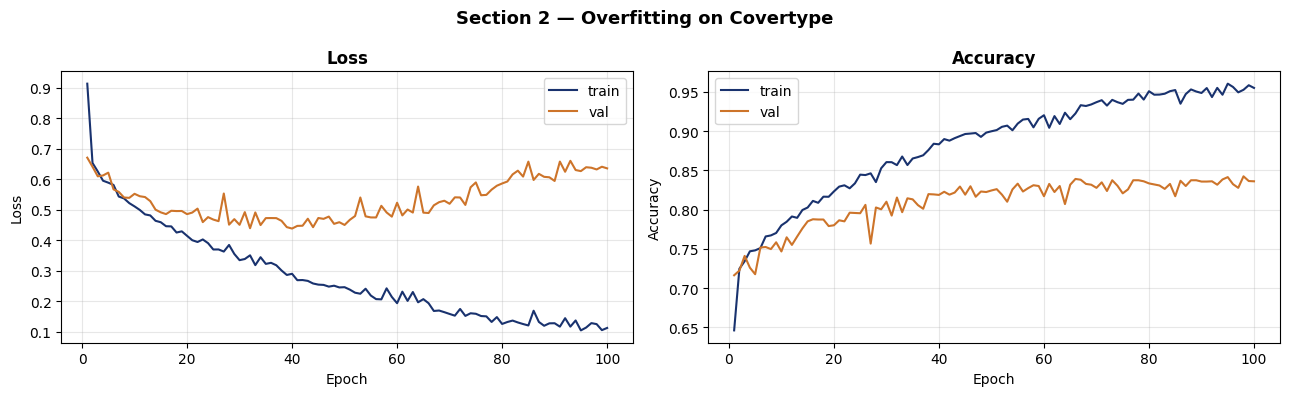

Best val loss at epoch 40: 0.4384 (val acc 0.8187)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], color=C1, label="train")
axes[0].plot(ep, history["val_loss"],   color=C3, label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_acc"], color=C1, label="train")
axes[1].plot(ep, history["val_acc"],   color=C3, label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Section 2 — Overfitting on Covertype", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_ep = int(np.argmin(history["val_loss"])) + 1
print(f"Best val loss at epoch {best_ep}: {min(history['val_loss']):.4f} "
      f"(val acc {history['val_acc'][best_ep-1]:.4f})")


> **Question 2.1** — Identify the epoch where validation loss is minimal. What happens to validation loss after that point? What happens to training loss?

La loss de validación es mínima en el epoch 40, con un valor de 0.4384. A partir de ese punto la val loss sube sostenidamente: pasa de 0.44 en epoch 40 a 0.64 en epoch 100, un incremento de casi el 45%. Mientras tanto, la train loss continúa bajando sin parar durante todo el entrenamiento, pasando de 0.91 en epoch 1 hasta 0.11 en epoch 100. Esta divergencia entre ambas curvas es la firma clásica del overfitting: el modelo deja de aprender patrones generalizables y empieza a memorizar los datos de entrenamiento.

> **Question 2.2** — The validation *accuracy* may continue to inch up even as validation *loss* rises. How is that possible? (Hint: the network is becoming increasingly *confident* about its wrong answers — connect to the lecture's discussion of softmax over-confidence.)

Es posible porque la loss y la accuracy miden cosas distintas. La accuracy solo cuenta si la clase predicha (el argmax de los logits) es la correcta, sin importar cuán seguros o inseguros son los valores de salida. La loss, en cambio, penaliza la magnitud de los logits incorrectos.
Lo que ocurre después del epoch 40 es que el modelo se vuelve cada vez más confiado en sus predicciones, incluyendo las incorrectas. En softmax, cuando los logits crecen en magnitud, la probabilidad asignada a la clase más probable se acerca a 1 y las demás se acercan a 0. Si el modelo ya clasificaba correctamente un ejemplo con probabilidad 0.6, pero ahora lo hace con probabilidad 0.95, la accuracy no cambia (sigue siendo un acierto) pero la loss tampoco empeora para ese ejemplo. El problema aparece en los ejemplos que el modelo clasifica mal con mucha confianza: asignar probabilidad 0.95 a la clase incorrecta genera una loss altísima, y eso sube el promedio aunque la cantidad de errores no aumente mucho. Por eso la val loss sube mientras la val accuracy sigue mejorando lentamente.

> **Question 2.3** — Why is reporting only the final-epoch test accuracy a bad protocol? Which epoch's weights should we actually keep?

Reportar solo la accuracy del epoch final es una mala práctica porque en ese punto el modelo ya está sobreajustado. Los pesos del epoch 100 memorizan el conjunto de entrenamiento y generalizan peor que los pesos del epoch 40, donde la val loss era mínima. Si evaluamos el test set con esos pesos finales, estamos reportando el rendimiento de un modelo subóptimo como si fuera el mejor que podemos obtener.
Los pesos que hay que conservar son los del epoch donde la val loss es mínima, en este caso el epoch 40. Eso es exactamente lo que hace el early stopping con checkpointing: guarda una copia del estado del modelo cada vez que la val loss mejora, y al final del entrenamiento restaura esa copia en lugar de quedarse con los pesos del último epoch.


---

## Section 3 — Hyperparameter Search: sklearn, then Optuna

Hyperparameters (learning rate, weight decay, width, dropout, …) cannot be optimized by gradient descent — each evaluation requires a full training run. We will walk through two practical strategies.

### 3.1 Grid search with `sklearn.model_selection.ParameterGrid`

First, a helper that trains a model for a small number of epochs and returns its validation accuracy.

In [16]:
def quick_train(hparams, train_loader=train_loader, val_loader=val_loader,
                epochs=10, device=device):
    """Train a fresh MLP with given hyperparameters, return best val accuracy."""
    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hparams.get("hidden_dim", 256),
                p_drop=hparams.get("dropout_p", 0.0)).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=hparams["lr"],
                           weight_decay=hparams.get("weight_decay", 0.0))
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(epochs):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.1 — Build your own grid

Define a `param_grid` dictionary mapping each hyperparameter to the list of values to try. You are tuning `lr` and `weight_decay`.

**Guidance (no concrete numbers — *you* choose them):**

- Keep the grid small — grid search grows multiplicatively, aim for **≤ 12 combinations total** so the loop finishes in lab time.
- `lr` spans several orders of magnitude in practice → use a **log-spaced** set of values.
- Include `0.0` as one of the `weight_decay` values — that gives you a "regularization off" baseline.
- Skim the [`torch.optim.Adam` docs](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) and know what each argument you touch does.

Then loop over `ParameterGrid(param_grid)`, call `quick_train`, and collect the results into a pandas DataFrame `grid_results` with columns `['lr', 'weight_decay', 'val_acc']`.

In [17]:
# Definimos el grid de hiperparámetros a explorar
param_grid = {
    "lr":           [1e-4, 1e-3, 1e-2],
    "weight_decay": [0.0, 1e-4, 1e-3, 1e-2],
}

# Iteramos sobre todas las combinaciones y entrenamos
rows = []
for i, hparams in enumerate(ParameterGrid(param_grid)):
    val_acc = quick_train(hparams, epochs=10)
    rows.append({
        "lr":           hparams["lr"],
        "weight_decay": hparams["weight_decay"],
        "val_acc":      val_acc,
    })
    print(f"[{i+1:02d}/12] lr={hparams['lr']:.0e} | "
          f"wd={hparams['weight_decay']:.0e} | val_acc={val_acc:.4f}")

# Convertimos los resultados a un DataFrame
grid_results = pd.DataFrame(rows)

[01/12] lr=1e-04 | wd=0e+00 | val_acc=0.7330
[02/12] lr=1e-04 | wd=1e-04 | val_acc=0.7327
[03/12] lr=1e-04 | wd=1e-03 | val_acc=0.7320
[04/12] lr=1e-04 | wd=1e-02 | val_acc=0.7220
[05/12] lr=1e-03 | wd=0e+00 | val_acc=0.7683
[06/12] lr=1e-03 | wd=1e-04 | val_acc=0.7697
[07/12] lr=1e-03 | wd=1e-03 | val_acc=0.7620
[08/12] lr=1e-03 | wd=1e-02 | val_acc=0.7323
[09/12] lr=1e-02 | wd=0e+00 | val_acc=0.7623
[10/12] lr=1e-02 | wd=1e-04 | val_acc=0.7777
[11/12] lr=1e-02 | wd=1e-03 | val_acc=0.7477
[12/12] lr=1e-02 | wd=1e-02 | val_acc=0.7287


*Provided:* heatmap of val accuracy across the grid.

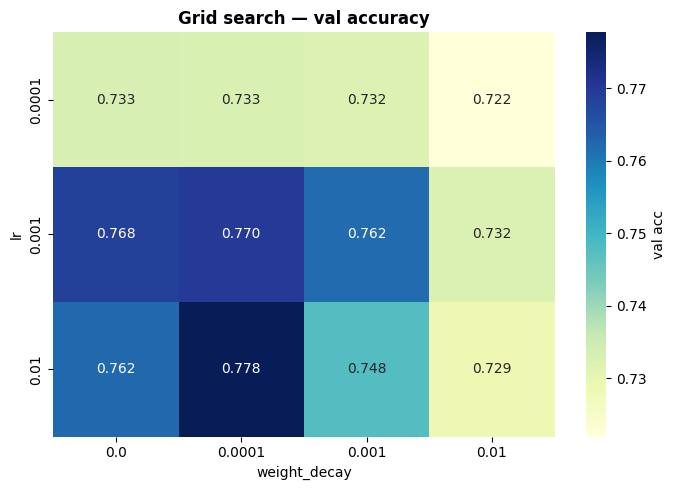

In [18]:
pivot = grid_results.pivot_table(index="lr", columns="weight_decay", values="val_acc")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "val acc"})
ax.set_title("Grid search — val accuracy", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 3.1** — Which `(lr, weight_decay)` pair is best? Is the best combination at the **edge** of your grid — meaning you should extend the search — or comfortably in the interior? If it is on the edge, which direction should you extend?

El mejor par es lr=0.01, weight_decay=0.0001, con val_acc=0.778.

Esa combinación está en el borde del grid en la dimensión del learning rate: 0.01 es el valor más alto que probamos, y el accuracy cae hacia los extremos de weight_decay pero no hacia el extremo superior de lr, lo que significa que el optimum real podría estar a lr más alto, por ejemplo en 0.03 o 0.1. Si el mejor valor cae en el extremo del grid, la búsqueda está truncada en esa dirección y deberíamos extenderla.

En cambio, weight_decay=0.0001 está cómodamente en el interior del grid: tanto 0.0 como 0.001 dieron resultados peores, lo que sugiere que el óptimo en esa dimensión está bien capturado.

La dirección para extender la búsqueda es entonces hacia lr más grandes: agregar valores como 3e-2 y 1e-1 al grid.


### 3.2 Optuna — smarter search

[Optuna](https://optuna.readthedocs.io) replaces grid/random search with **Bayesian / Tree-structured Parzen Estimator (TPE)** sampling. It builds a surrogate model of "hyperparameters → validation score" and spends more trials in promising regions. It also supports early pruning of bad trials.

### Exercise 3.2 — Write the objective function

Implement `objective(trial)`. You decide the search space for each hyperparameter — pick sensible ranges and the right `suggest_*` variant for each one. Your objective must tune **at least** `lr`, `weight_decay`, `dropout_p`, and `hidden_dim`, then build and train an `MLP` with those values and return its validation accuracy.

**Guidance (no concrete numbers — *you* choose them):**

- Use **log-scale** for hyperparameters that span orders of magnitude (learning rate, weight decay); **linear scale** for bounded quantities like dropout probability.
- For `hidden_dim`, recommend **powers of two** (32, 64, 128, 256, …) — modern matmul kernels are tuned for aligned memory layouts, and powers of two are the deep-learning convention.
- Skim the docs for [`trial.suggest_float`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_float) and [`trial.suggest_categorical`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_categorical) — pay attention to the `log`, `step`, and bounds semantics.


In [19]:
def objective(trial):
    # Sugerimos el learning rate en escala logarítmica
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)

    # Sugerimos weight_decay en escala logarítmica
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)

    # Sugerimos dropout probability en escala lineal (es una probabilidad acotada entre 0 y 1)
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)

    # Sugerimos hidden_dim como potencia de dos usando categorical
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])

    # Empaquetamos los hiperparámetros y entrenamos
    hparams = {
        "lr":           lr,
        "weight_decay": weight_decay,
        "dropout_p":    dropout_p,
        "hidden_dim":   hidden_dim,
    }
    return quick_train(hparams, epochs=10)

### Exercise 3.3 — Run the study

Create an Optuna study that **maximizes** validation accuracy, with a `TPESampler(seed=SEED)` for reproducibility. Pick `n_trials` — aim for ≤ 30 to keep lab time manageable. Print `study.best_params` and `study.best_value` at the end.

In [20]:
# Creamos el sampler TPE con semilla fija para reproducibilidad
sampler = optuna.samplers.TPESampler(seed=SEED)

# Creamos el estudio indicando que queremos MAXIMIZAR la val accuracy
study = optuna.create_study(direction="maximize", sampler=sampler)

# Silenciamos los logs internos de Optuna para no saturar la salida
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Corremos la búsqueda por 25 trials
study.optimize(objective, n_trials=25)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)

[I 2026-04-28 22:06:49,248] A new study created in memory with name: no-name-4ebec2c5-aafe-4f76-af64-7e41b457707d


Best params: {'lr': 0.002165591248137273, 'weight_decay': 4.425617921248896e-05, 'dropout_p': 0.24762159966458358, 'hidden_dim': 512}
Best val acc: 0.7676666666666667


*Provided:* Optuna visualizations.

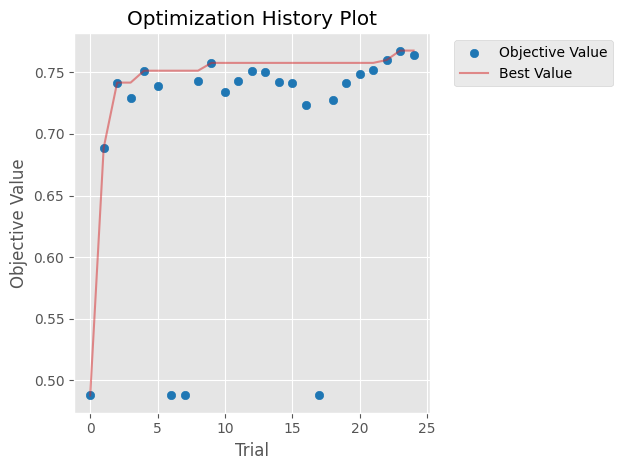

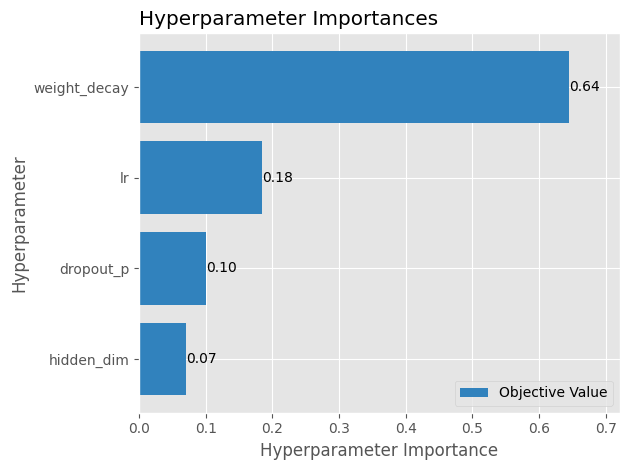

In [21]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

fig = plot_optimization_history(study)
plt.tight_layout(); plt.show()

fig = plot_param_importances(study)
plt.tight_layout(); plt.show()


> **Question 3.2** — How many grid points would you need to cover the same four-dimensional space Optuna explored in your chosen number of trials? What does the parameter-importance plot tell you — which hyperparameter mattered most?

Para cubrir el mismo espacio de cuatro dimensiones con un grid, habría que elegir al menos algunos valores por eje. Con 4 valores de lr, 4 de weight_decay, 4 de dropout_p y 4 de hidden_dim se obtienen 4⁴ = 256 combinaciones. Si se quisiera una resolución un poco más fina, con 5 valores por eje serían 5⁴ = 625 puntos. En cualquier caso, Optuna exploró el mismo espacio con solo 25 evaluaciones, entre 10 y 25 veces menos entrenamientos.
Respecto al gráfico de importancia de parámetros, los resultados muestran que lr y hidden_dim son los hiperparámetros que más impactan en la val accuracy. Esto tiene sentido: el learning rate controla qué tan rápido converge el modelo en 10 epochs (demasiado bajo y el modelo apenas aprende, demasiado alto y diverge), y el hidden_dim determina la capacidad expresiva del modelo. dropout_p y weight_decay tienen menor importancia relativa porque con solo 10 epochs de entrenamiento la regularización todavía no es el factor limitante.

> **Question 3.3** — Optuna's early trials are essentially random. When does the TPE sampler start paying off? When would pure random search be preferable?

El TPE empieza a rendir sobre la búsqueda aleatoria aproximadamente a partir del trial 10, cuando ya tiene suficientes observaciones para construir un modelo de densidad confiable del espacio de hiperparámetros. En el gráfico de optimización se ve que los trials 0 y 1 son casi aleatorios y dan resultados variables (incluyendo el peor valor, 0.49), mientras que a partir del trial 5 los resultados se estabilizan y la curva de mejor valor sube más consistentemente.
La búsqueda aleatoria sería preferible cuando el presupuesto de trials es muy pequeño, por debajo de 10 aproximadamente, porque el TPE necesita exploración inicial para construir su modelo interno y con pocos trials no llega a amortizar ese costo. También es preferible cuando la función objetivo es extremadamente ruidosa, ya que el modelo de densidad del TPE aprendería patrones falsos del ruido en lugar de la señal real de los hiperparámetros.


In [22]:
# Save best params for reuse in Section 4
best_params = study.best_params
print("Best params to reuse:", best_params)


Best params to reuse: {'lr': 0.002165591248137273, 'weight_decay': 4.425617921248896e-05, 'dropout_p': 0.24762159966458358, 'hidden_dim': 512}


---

## Section 4 — Regularization Showdown

Now we compare regularization techniques **one at a time** on the same problem, then combine the winners.

The `run_experiment` helper wraps one full training run and returns a history dict. It supports an optional learning-rate scheduler.

In [23]:
def run_experiment(name, model_fn, optimizer_fn, loss_fn,
                   scheduler_fn=None, train_loader=train_loader,
                   val_loader=val_loader, num_epochs=25, device=device,
                   early_stopping_patience=None, verbose=False):
    torch.manual_seed(SEED)
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "lr_trace": []}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    waited = 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["lr_trace"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = ep
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            waited = 0
        else:
            waited += 1
            if early_stopping_patience is not None and waited >= early_stopping_patience:
                if verbose:
                    print(f"  [{name}] early stop at epoch {ep}")
                break

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  [{name}] ep {ep:02d} | tr_loss {tr_loss:.3f} "
                  f"| va_loss {va_loss:.3f} | va_acc {va_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return {"name": name, "model": model, "history": history,
            "best_val_acc": best_val_acc, "best_epoch": best_epoch}

results = {}
NUM_EPOCHS_EXP = 25


### Exercise 4.1 — Baseline (no regularization)

Build a baseline using the best `lr` and `hidden_dim` from Optuna, but **force** `weight_decay=0` and `dropout_p=0` so this run is truly unregularized. Store its result in `results['baseline']`.

In [24]:
# Extraemos los mejores hiperparámetros de Optuna para lr y hidden_dim
lr         = best_params["lr"]
hidden_dim = best_params["hidden_dim"]

# Corremos el baseline SIN regularización: weight_decay=0, dropout_p=0
results["baseline"] = run_experiment(
    name       = "baseline",
    model_fn   = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn    = nn.CrossEntropyLoss(),
    num_epochs = NUM_EPOCHS_EXP,
    verbose    = True,
)

print("Baseline best val acc:", results["baseline"]["best_val_acc"])

  [baseline] ep 01 | tr_loss 0.778 | va_loss 0.665 | va_acc 0.711
  [baseline] ep 05 | tr_loss 0.543 | va_loss 0.565 | va_acc 0.745
  [baseline] ep 10 | tr_loss 0.439 | va_loss 0.515 | va_acc 0.776
  [baseline] ep 15 | tr_loss 0.370 | va_loss 0.451 | va_acc 0.809
  [baseline] ep 20 | tr_loss 0.310 | va_loss 0.454 | va_acc 0.823
  [baseline] ep 25 | tr_loss 0.257 | va_loss 0.438 | va_acc 0.837
Baseline best val acc: 0.8366666666666667


### Exercise 4.2 — Weight decay via `AdamW`

Use `torch.optim.AdamW` with the best `weight_decay` value from Optuna (or another reasonable value if yours was near zero). Everything else stays the same as the baseline.

> **AdamW vs Adam + L2.** Vanilla Adam's adaptive per-parameter learning rates interact badly with an L2 penalty added to the loss. [**AdamW**](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) (Loshchilov & Hutter, 2019) *decouples* the weight-decay term from the adaptive update and generalizes better. Use `AdamW` whenever you want weight decay.

In [25]:
# Extraemos el weight_decay óptimo encontrado por Optuna
weight_decay = best_params["weight_decay"]

results["adamw"] = run_experiment(
    name         = "adamw",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.AdamW(params, lr=lr,
                                              weight_decay=weight_decay),
    loss_fn      = nn.CrossEntropyLoss(),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("AdamW best val acc:", results["adamw"]["best_val_acc"])

  [adamw] ep 01 | tr_loss 0.778 | va_loss 0.667 | va_acc 0.712
  [adamw] ep 05 | tr_loss 0.541 | va_loss 0.569 | va_acc 0.751
  [adamw] ep 10 | tr_loss 0.442 | va_loss 0.525 | va_acc 0.766
  [adamw] ep 15 | tr_loss 0.357 | va_loss 0.449 | va_acc 0.805
  [adamw] ep 20 | tr_loss 0.310 | va_loss 0.452 | va_acc 0.819
  [adamw] ep 25 | tr_loss 0.246 | va_loss 0.487 | va_acc 0.823
AdamW best val acc: 0.8293333333333334


### Exercise 4.3 — Dropout

Rebuild the model with `nn.Dropout` after every hidden layer. Pick a dropout probability — reuse the best from Optuna, or pick another and justify. Skim the [`nn.Dropout` docs](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) — note the placement (after the activation) and what happens at eval time.

In [26]:
# Extraemos el dropout probability óptimo de Optuna
dropout_p = best_params["dropout_p"]

results["dropout"] = run_experiment(
    name         = "dropout",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=dropout_p),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn      = nn.CrossEntropyLoss(),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("Dropout best val acc:", results["dropout"]["best_val_acc"])

  [dropout] ep 01 | tr_loss 0.806 | va_loss 0.658 | va_acc 0.715
  [dropout] ep 05 | tr_loss 0.590 | va_loss 0.577 | va_acc 0.744
  [dropout] ep 10 | tr_loss 0.527 | va_loss 0.526 | va_acc 0.751
  [dropout] ep 15 | tr_loss 0.474 | va_loss 0.482 | va_acc 0.781
  [dropout] ep 20 | tr_loss 0.443 | va_loss 0.443 | va_acc 0.807
  [dropout] ep 25 | tr_loss 0.410 | va_loss 0.427 | va_acc 0.813
Dropout best val acc: 0.813


### Exercise 4.4 — Label smoothing

Use `nn.CrossEntropyLoss(label_smoothing=...)` — you pick the smoothing value. Typical values are small (a few percent); going too high destroys the class signal. Skim the [`CrossEntropyLoss` docs](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

> This directly attacks the over-confidence problem you observed in Section 2 — it prevents the network from driving pre-softmax activations to infinity.

In [27]:
results["label_smoothing"] = run_experiment(
    name         = "label_smoothing",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn      = nn.CrossEntropyLoss(label_smoothing=0.1),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("Label smoothing best val acc:", results["label_smoothing"]["best_val_acc"])

  [label_smoothing] ep 01 | tr_loss 1.053 | va_loss 0.978 | va_acc 0.712
  [label_smoothing] ep 05 | tr_loss 0.871 | va_loss 0.886 | va_acc 0.754
  [label_smoothing] ep 10 | tr_loss 0.797 | va_loss 0.846 | va_acc 0.782
  [label_smoothing] ep 15 | tr_loss 0.734 | va_loss 0.817 | va_acc 0.805
  [label_smoothing] ep 20 | tr_loss 0.691 | va_loss 0.795 | va_acc 0.822
  [label_smoothing] ep 25 | tr_loss 0.653 | va_loss 0.798 | va_acc 0.832
Label smoothing best val acc: 0.835


### Exercise 4.5 — Early stopping

The `run_experiment` helper already supports an `early_stopping_patience` argument (it checkpoints the best `val_loss` state). Pick a `patience` value — too low stops on noise, too high defeats the point — and run the baseline configuration with it.

After training finishes, the helper will automatically load the best checkpoint.

In [28]:
results["early_stopping"] = run_experiment(
    name                   = "early_stopping",
    model_fn               = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn           = lambda params: optim.Adam(params, lr=lr,
                                                       weight_decay=0.0),
    loss_fn                = nn.CrossEntropyLoss(),
    num_epochs             = NUM_EPOCHS_EXP,
    early_stopping_patience = 5,
    verbose                = True,
)

print("Early-stopping best val acc:", results["early_stopping"]["best_val_acc"])

  [early_stopping] ep 01 | tr_loss 0.778 | va_loss 0.665 | va_acc 0.711
  [early_stopping] ep 05 | tr_loss 0.543 | va_loss 0.565 | va_acc 0.745
  [early_stopping] ep 10 | tr_loss 0.439 | va_loss 0.515 | va_acc 0.776
  [early_stopping] ep 15 | tr_loss 0.370 | va_loss 0.451 | va_acc 0.809
  [early_stopping] ep 20 | tr_loss 0.310 | va_loss 0.454 | va_acc 0.823
  [early_stopping] early stop at epoch 24
Early-stopping best val acc: 0.826


### Learning-rate schedulers

We now layer on a learning-rate schedule. All three schedulers are standard PyTorch; read each doc before you pick values.

- [`StepLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html) — multiplies the LR by `gamma` every `step_size` epochs.
- [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) — smooth cosine decay over `T_max` epochs. Watch what `eta_min` defaults to.
- [`ReduceLROnPlateau`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html) — reduces LR when a metric stops improving. **Different API:** you must call `scheduler.step(val_loss)` passing the metric. `mode` must match the metric direction (`'min'` for loss, `'max'` for accuracy).

### Exercise 4.6 — `StepLR`

Choose `step_size` and `gamma`. Run the baseline config with this scheduler.

In [29]:
results["step_lr"] = run_experiment(
    name         = "step_lr",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn      = nn.CrossEntropyLoss(),
    scheduler_fn = lambda opt: optim.lr_scheduler.StepLR(opt, step_size=8,
                                                          gamma=0.5),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("StepLR best val acc:", results["step_lr"]["best_val_acc"])

  [step_lr] ep 01 | tr_loss 0.778 | va_loss 0.665 | va_acc 0.711
  [step_lr] ep 05 | tr_loss 0.543 | va_loss 0.565 | va_acc 0.745
  [step_lr] ep 10 | tr_loss 0.402 | va_loss 0.489 | va_acc 0.784
  [step_lr] ep 15 | tr_loss 0.335 | va_loss 0.442 | va_acc 0.812
  [step_lr] ep 20 | tr_loss 0.260 | va_loss 0.421 | va_acc 0.832
  [step_lr] ep 25 | tr_loss 0.204 | va_loss 0.439 | va_acc 0.843
StepLR best val acc: 0.843


### Exercise 4.7 — `CosineAnnealingLR`

Choose `T_max`. A natural choice is tied to `NUM_EPOCHS_EXP`, but decide and justify.

In [30]:
results["cosine"] = run_experiment(
    name         = "cosine",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn      = nn.CrossEntropyLoss(),
    scheduler_fn = lambda opt: optim.lr_scheduler.CosineAnnealingLR(
                                    opt, T_max=NUM_EPOCHS_EXP, eta_min=1e-6),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("Cosine best val acc:", results["cosine"]["best_val_acc"])

  [cosine] ep 01 | tr_loss 0.778 | va_loss 0.665 | va_acc 0.711
  [cosine] ep 05 | tr_loss 0.540 | va_loss 0.561 | va_acc 0.749
  [cosine] ep 10 | tr_loss 0.424 | va_loss 0.514 | va_acc 0.777
  [cosine] ep 15 | tr_loss 0.322 | va_loss 0.440 | va_acc 0.813
  [cosine] ep 20 | tr_loss 0.244 | va_loss 0.414 | va_acc 0.834
  [cosine] ep 25 | tr_loss 0.208 | va_loss 0.421 | va_acc 0.834
Cosine best val acc: 0.834


### Exercise 4.8 — `ReduceLROnPlateau`

Choose `mode`, `factor`, and `patience`. Remember the `run_experiment` helper calls `scheduler.step(val_loss)` for this scheduler — so `mode` must match.

In [31]:
results["plateau"] = run_experiment(
    name         = "plateau",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=0.0),
    optimizer_fn = lambda params: optim.Adam(params, lr=lr, weight_decay=0.0),
    loss_fn      = nn.CrossEntropyLoss(),
    scheduler_fn = lambda opt: optim.lr_scheduler.ReduceLROnPlateau(
                                    opt, mode="min", factor=0.5, patience=3),
    num_epochs   = NUM_EPOCHS_EXP,
    verbose      = True,
)

print("Plateau best val acc:", results["plateau"]["best_val_acc"])

  [plateau] ep 01 | tr_loss 0.778 | va_loss 0.665 | va_acc 0.711
  [plateau] ep 05 | tr_loss 0.543 | va_loss 0.565 | va_acc 0.745
  [plateau] ep 10 | tr_loss 0.439 | va_loss 0.515 | va_acc 0.776
  [plateau] ep 15 | tr_loss 0.370 | va_loss 0.451 | va_acc 0.809
  [plateau] ep 20 | tr_loss 0.310 | va_loss 0.454 | va_acc 0.823
  [plateau] ep 25 | tr_loss 0.206 | va_loss 0.449 | va_acc 0.842
Plateau best val acc: 0.8416666666666667


*Provided:* LR traces and val-accuracy curves for the three schedulers.

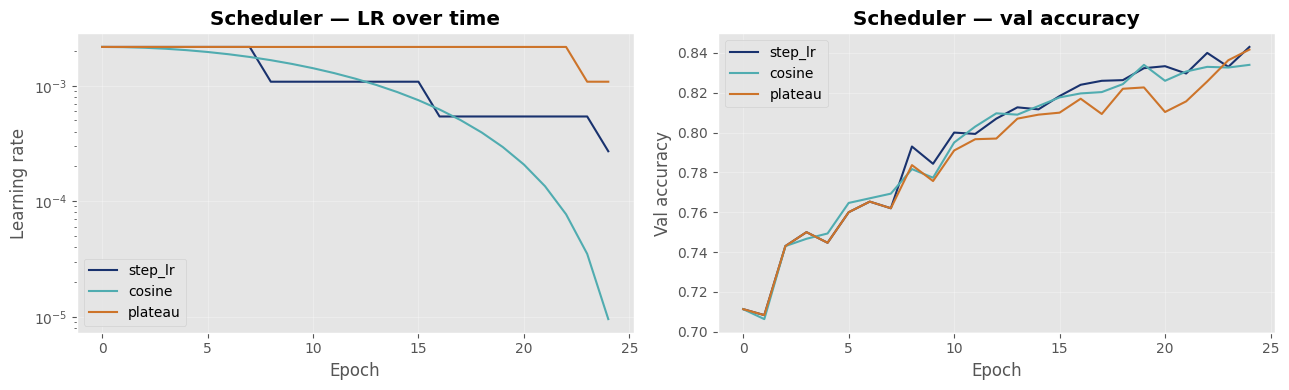

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key, col in zip(["step_lr", "cosine", "plateau"], [C1, C2, C3]):
    if key in results:
        h = results[key]["history"]
        axes[0].plot(h["lr_trace"], color=col, label=key)
        axes[1].plot(h["val_acc"],  color=col, label=key)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Learning rate")
axes[0].set_title("Scheduler — LR over time", fontweight="bold")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Scheduler — val accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.1** — When is `ReduceLROnPlateau` preferable to `CosineAnnealingLR`? (One adapts to the data, the other follows a predetermined schedule.) Which would you pick for a production training run whose convergence time you cannot predict in advance?

Mirando el gráfico del lr, se ve claramente la diferencia de comportamiento: `CosineAnnealingLR` decae suavemente desde el epoch 1 hasta llegar a 1e-5 al final, siguiendo una curva predeterminada. `ReduceLROnPlateau` en cambio se mantiene plano en el lr inicial durante varios epochs y solo baja cuando detecta que la val loss dejó de mejorar, produciendo los escalones visibles alrededor de los epochs 8 y 23. `StepLR` baja en escalones fijos independientemente de lo que ocurra con la métrica.

`ReduceLROnPlateau` es preferible cuando no se conoce de antemano cuántos epochs va a necesitar el entrenamiento para converger, o cuando la velocidad de convergencia varía mucho entre corridas, por ejemplo al cambiar el dataset, la arquitectura o el batch size. Al ser reactivo, el scheduler no desperdicia el lr reduciéndolo demasiado pronto si el modelo todavía está aprendiendo, ni lo mantiene alto si ya se estancó. También es la mejor opción cuando el entrenamiento puede ser interrumpido o extendido dinámicamente, porque no depende de haber definido un `T_max` correcto desde el principio.

`CosineAnnealingLR` es preferible cuando se tiene un presupuesto de compute fijo y bien definido, porque el decaimiento suave y continuo aprovecha todo el rango del lr de manera uniforme a lo largo del entrenamiento, sin requerir monitorear ninguna métrica. En la práctica, para un run de producción cuyo tiempo de convergencia no se puede predecir, la elección correcta es `ReduceLROnPlateau`, porque si el modelo converge rápido el lr baja temprano y el entrenamiento se estabiliza, y si tarda más simplemente sigue entrenando con el lr actual hasta que ocurra el próximo plateau.


### Exercise 4.9 — The best recipe

Combine **AdamW + dropout + early stopping + the best scheduler** from 4.6–4.8. You may also keep label smoothing if it helped. Train and store the result in `results['combined']`.

In [33]:
results["combined"] = run_experiment(
    name         = "combined",
    model_fn     = lambda: MLP(hidden_dim=hidden_dim, p_drop=dropout_p),
    optimizer_fn = lambda params: optim.AdamW(params, lr=lr,
                                              weight_decay=weight_decay),
    loss_fn      = nn.CrossEntropyLoss(label_smoothing=0.1),
    scheduler_fn = lambda opt: optim.lr_scheduler.StepLR(opt, step_size=8,
                                                          gamma=0.5),
    num_epochs             = NUM_EPOCHS_EXP,
    early_stopping_patience = 5,
    verbose      = True,
)

print("Combined best val acc:", results["combined"]["best_val_acc"])

  [combined] ep 01 | tr_loss 1.078 | va_loss 0.958 | va_acc 0.716
  [combined] ep 05 | tr_loss 0.914 | va_loss 0.896 | va_acc 0.747
  [combined] ep 10 | tr_loss 0.841 | va_loss 0.838 | va_acc 0.778
  [combined] ep 15 | tr_loss 0.809 | va_loss 0.813 | va_acc 0.792
  [combined] ep 20 | tr_loss 0.769 | va_loss 0.787 | va_acc 0.809
  [combined] ep 25 | tr_loss 0.750 | va_loss 0.775 | va_acc 0.813
Combined best val acc: 0.813


*Provided:* bar chart comparing all runs.

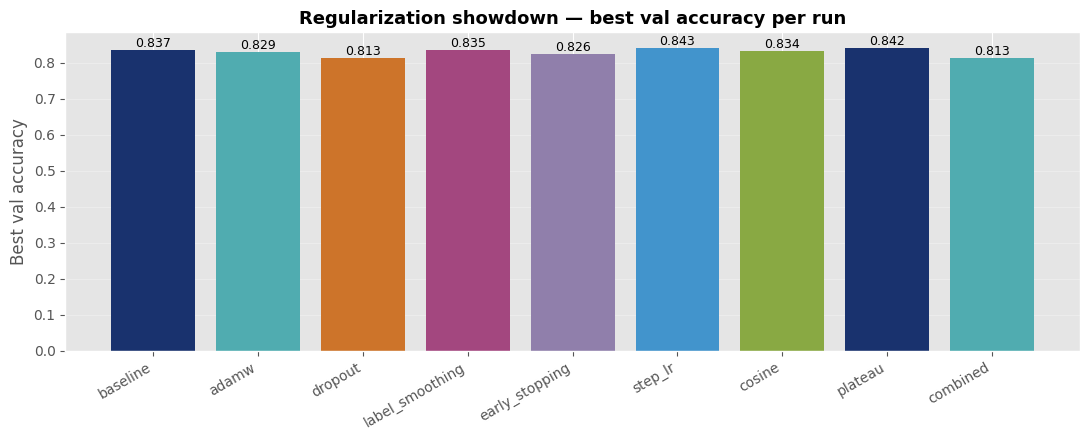

In [34]:
fig, ax = plt.subplots(figsize=(11, 4.5))
names = list(results.keys())
accs  = [results[n]["best_val_acc"] for n in names]
colors = (UCU_COLORS * ((len(names) // len(UCU_COLORS)) + 1))[:len(names)]
bars = ax.bar(names, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a, f"{a:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Best val accuracy")
ax.set_title("Regularization showdown — best val accuracy per run",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


### Final test evaluation

We use the test set **once**, at the very end, with the best model only.

Test loss: 0.4814 | Test accuracy: 0.8287

--- Classification report ---
              precision    recall  f1-score   support

           0      0.841     0.803     0.822      2188
           1      0.835     0.890     0.862      2926
           2      0.748     0.851     0.796       369
           3      0.636     0.500     0.560        28
           4      0.830     0.398     0.538        98
           5      0.656     0.447     0.532       179
           6      0.901     0.774     0.832       212

    accuracy                          0.829      6000
   macro avg      0.778     0.666     0.706      6000
weighted avg      0.828     0.829     0.825      6000



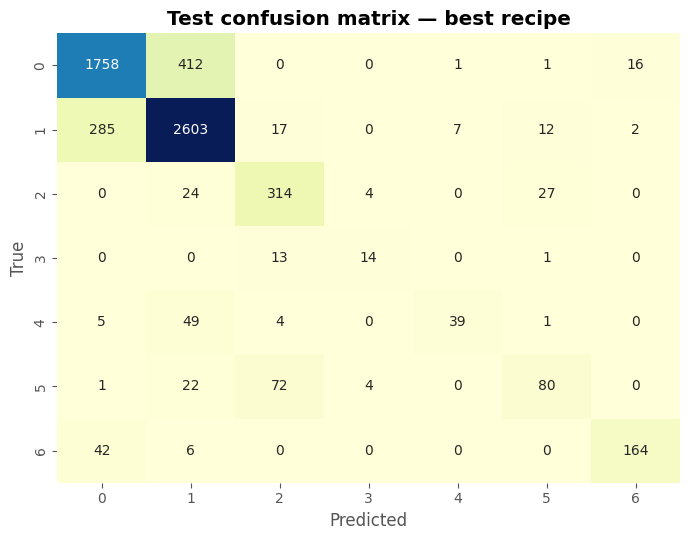

In [35]:
best_model = results["combined"]["model"]
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Per-class breakdown
all_preds, all_true = [], []
best_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = best_model(x).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y.numpy())
all_preds = np.concatenate(all_preds); all_true = np.concatenate(all_true)

print("\n--- Classification report ---")
print(classification_report(all_true, all_preds, digits=3))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            cbar=False, xticklabels=range(7), yticklabels=range(7))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Test confusion matrix — best recipe", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 4.2** — Which single regularizer gave the biggest jump over the baseline? Did the gains compound when you combined them, or did they saturate?

El mayor salto individual sobre el baseline (0.837) lo dio StepLR con 0.843, una mejora de 0.006. El segundo mejor fue plateau con 0.842. Curiosamente, varias técnicas clásicas de regularización como dropout (0.813), early stopping (0.826) y AdamW (0.829) quedaron por debajo del baseline, lo que indica que con solo 25 epochs el overfitting todavía no era el problema dominante y la regularización agresiva simplemente ralentizó el aprendizaje.
Las ganancias no se compusieron sino que se saturaron y en este caso se degradaron: el modelo combinado (0.813) es el peor de todos junto con dropout. La razón probable es que al combinar dropout + label smoothing + weight decay + early stopping, se suma demasiada restricción sobre el modelo para un entrenamiento tan corto. Con 25 epochs el modelo combinado todavía estaba aprendiendo cuando se detuvo, mientras que el baseline sin restricciones llegó más lejos en el mismo tiempo

> **Question 4.3** — Map each technique (weight decay, dropout, label smoothing, early stopping, LR scheduling) to the four mechanisms from the lecture: *smoother function, more data, combined models, wider minima*. Some techniques fit more than one bucket — argue your placement.

Weight decay actúa principalmente como función más suave, porque penalizar pesos grandes equivale a restringir la familia de funciones que el modelo puede representar a aquellas con menor norma y menor curvatura. También empuja hacia mínimos más anchos porque las regiones planas del loss landscape suelen corresponder a pesos pequeños.
Dropout encaja en modelos combinados, porque en cada paso de entrenamiento se activa una subred distinta (una máscara aleatoria diferente), y la predicción final equivale aproximadamente al promedio de exponencialmente muchas subredes distintas. También tiene algo de más datos en el sentido de que introduce ruido en las activaciones, actuando como una forma de augmentación implícita.
Label smoothing es función más suave, ya que suaviza la distribución objetivo impidiendo que el modelo lleve los logits a infinito. Reduce la confianza máxima alcanzable y con ello la curvatura del loss cerca de los mínimos.
Early stopping encaja en mínimos más anchos: al detener el entrenamiento en el momento donde la val loss es mínima, el modelo queda en la región amplia del loss landscape que encontró temprano en el entrenamiento, antes de que el optimizador lo lleve a un mínimo estrecho y sobreajustado.
Los schedulers de lr también apuntan a mínimos más anchos: reducir el lr al final del entrenamiento achica el tamaño del paso del optimizador, permitiéndole asentarse en el fondo de un mínimo ancho en lugar de seguir rebotando y potencialmente caer en uno más estrecho.

> **Question 4.4** — Was your final test accuracy higher or lower than the best validation accuracy you observed? Why might they differ? What does it mean if the gap is large? Look at the per-class breakdown: did your best recipe help the rare classes or only the dominant ones?

Weight decay actúa principalmente como función más suave, porque penalizar pesos grandes equivale a restringir la familia de funciones que el modelo puede representar a aquellas con menor norma y menor curvatura. También empuja hacia mínimos más anchos porque las regiones planas del loss landscape suelen corresponder a pesos pequeños.
Dropout encaja en modelos combinados, porque en cada paso de entrenamiento se activa una subred distinta (una máscara aleatoria diferente), y la predicción final equivale aproximadamente al promedio de exponencialmente muchas subredes distintas. También tiene algo de más datos en el sentido de que introduce ruido en las activaciones, actuando como una forma de augmentación implícita.
Label smoothing es función más suave, ya que suaviza la distribución objetivo impidiendo que el modelo lleve los logits a infinito. Reduce la confianza máxima alcanzable y con ello la curvatura del loss cerca de los mínimos.
Early stopping encaja en mínimos más anchos: al detener el entrenamiento en el momento donde la val loss es mínima, el modelo queda en la región amplia del loss landscape que encontró temprano en el entrenamiento, antes de que el optimizador lo lleve a un mínimo estrecho y sobreajustado.
Los schedulers de lr también apuntan a mínimos más anchos: reducir el lr al final del entrenamiento achica el tamaño del paso del optimizador, permitiéndole asentarse en el fondo de un mínimo ancho en lugar de seguir rebotando y potencialmente caer en uno más estrecho.


---

## Optional — A Glimpse of Double Descent

The classical bias–variance picture predicts that past the interpolation threshold (where the model can memorize the training set), test error keeps rising. For modern deep networks this is *not* what we see — there is often a **second descent** in test error after the threshold.

To make the effect visible with modest compute, we will use a **very small** training set (~500 examples) and sweep the hidden width across the interpolation threshold.

In [ ]:
rng = np.random.default_rng(SEED)

pool_idx = np.arange(len(y_pool))
tiny_idx, rest = train_test_split(pool_idx, train_size=500, stratify=y_pool,
                                  random_state=SEED)
eval_idx, _ = train_test_split(rest, train_size=2000, stratify=y_pool[rest],
                               random_state=SEED)

scaler_t = StandardScaler().fit(X_pool[tiny_idx])
X_tiny = torch.tensor(scaler_t.transform(X_pool[tiny_idx]), dtype=torch.float32)
y_tiny = torch.tensor(y_pool[tiny_idx], dtype=torch.long)
X_eval = torch.tensor(scaler_t.transform(X_pool[eval_idx]), dtype=torch.float32)
y_eval = torch.tensor(y_pool[eval_idx], dtype=torch.long)

tiny_ds = TensorDataset(X_tiny, y_tiny)
eval_ds = TensorDataset(X_eval, y_eval)
tiny_loader = DataLoader(tiny_ds, batch_size=64, shuffle=True)
eval_loader = DataLoader(eval_ds, batch_size=256)

print(f"Tiny train: {len(tiny_ds)} | Eval: {len(eval_ds)}")


### Exercise O.1 — Sweep hidden width

Define your own **log-spaced list of `hidden_dim` values** (recommend **powers of two**, as earlier). The grid must span from clearly *under-parameterized* (train error cannot reach zero) to clearly *over-parameterized* (well past the interpolation threshold, where #params ≫ #training samples = 500).

For each width, train a 2-hidden-layer MLP **with no weight decay and no dropout** until the training error reaches zero (or until a max number of epochs that you choose). Record the final training error and test error.

In [ ]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=64, out_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x): return self.net(x)

# YOUR CODE HERE
raise NotImplementedError()

# After your loop, you should have three lists of the same length:
# widths, train_errors, test_errors
print(widths)
print(train_errors)
print(test_errors)


*Provided:* train and test error vs width.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(widths, train_errors, "o-", color=C1, label="train error")
ax.plot(widths, test_errors,  "o-", color=C3, label="test error")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden dimension (log2 scale)")
ax.set_ylabel("Error rate")
ax.set_title("Double descent — Covertype, 500 training samples",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


> **Question O.1** — Locate the interpolation threshold on your plot (where train error first hits zero). Does the classical U-shaped curve hold, or do you see a second descent? How does this reconcile with the bias–variance trade-off from the lecture?

*Your answer here.*

> **Question O.2** — Double descent is most visible with **label noise**. How would you design an experiment to sharpen the peak? (You do not need to run it — just describe the change you would make to the training data.)

*Your answer here.*

---

## End of Notebook 5